# Stage A' — high-entropy carbide solid-solution (SQS) construction (CO2RR)

Builds special quasi-random structures (SQS) for the economic CO2RR-to-CO high-entropy
carbide shortlist (`outputs/gen_co2rr_economic/top_HEC_co2rr.csv`), via Monte-Carlo
pair-correlation matching (`carbidemattergen.solid_solution`, no icet needed). Each metal
sublattice is occupied near-equimolar with the candidate's palette and annealed to minimise
the pair-correlation error Φ.

Reads `outputs/sqs/sqs_summary.csv` (from `scripts/35_build_solid_solutions.py`). The columns
`best_site` / `frac_tn` here carry the **CO2RR** descriptors (best-site ΔG_CO and CO-selective
fraction) of the parent composition. The Φ-reduction and framework panels are reaction-agnostic
SQS-quality metrics. **Re-runnable.**


In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

ROOT = Path('/home/jonglee69/mattergen/CarbideMatterGen'); sys.path.insert(0, str(ROOT))
SQS = ROOT / 'outputs' / 'sqs'; FIG = ROOT / 'figures'; FIG.mkdir(exist_ok=True)
NATURE_RC = {'font.family':'sans-serif','font.sans-serif':['Arial','DejaVu Sans'],
    'font.size':8,'axes.labelsize':8,'axes.titlesize':9,'xtick.labelsize':7,
    'ytick.labelsize':7,'legend.fontsize':7,'axes.linewidth':0.6,
    'xtick.direction':'in','ytick.direction':'in','legend.frameon':False,
    'pdf.fonttype':42,'savefig.bbox':'tight','savefig.dpi':300}
mpl.rcParams.update(NATURE_RC)
OI = {'blue':'#0072B2','vermil':'#D55E00','green':'#009E73','orange':'#E69F00','purple':'#CC79A7'}
s = pd.read_csv(SQS / 'sqs_summary.csv')
print(f'{len(s)} solid solutions built')
s[['rank','source_formula','sqs_formula','framework','n_metal_sites','phi_random','phi_sqs','phi_reduction','S_mix','w']]

20 solid solutions built


,rank,source_formula,sqs_formula,framework,n_metal_sites,phi_random,phi_sqs,phi_reduction,S_mix,w
0,1,SmGd3HoRe2GeMo3WC7,Sm8Gd8Ho8Re8Ge8Mo7W7C27,hcp_M2C,54,0.00073,0.00022,3.40,1.820,w2p5
1,2,TmReGe2Mo2Ru2W2C,TmReGeMoRuWC3,hcp_M2C,54,0.00240,0.00002,158.85,1.748,w2p5
2,3,GdLu2GeMoOs2Ru2C3,GdLuGeMoOsRuC3,hcp_M2C,54,0.00240,0.00002,158.85,1.735,w2p5
3,4,Ho3GeMo3Os4Ru2W3C4,HoGeMoOsRuWC3,hcp_M2C,54,0.00240,0.00002,158.85,1.721,w2p5
4,5,Tb2Dy2Ge4Ir2Os2Ru5C3,TbDyGeIrOsRuC3,hcp_M2C,54,0.00240,0.00002,158.85,1.707,w2p5
5,6,Sm3Re3Ge5Mo2Ir4WC2,SmReGeMoIrWC3,hcp_M2C,54,0.00240,0.00002,158.85,1.692,w2p5
6,7,CeNdGd2OsRu4(WC2)2,CeNdGdOsRuWC3,hcp_M2C,54,0.00240,0.00002,158.85,1.642,w2p5
7,8,Pr3Dy2TmGe6Os2(WC2)2,PrDyTmGeOsWC3,hcp_M2C,54,0.00240,0.00002,158.85,1.635,w2p5
8,9,SmGd3CrRe2Mo4RuC8,SmGdCrReMoRuC6,rocksalt_MC,108,0.00078,0.00009,8.63,1.633,w2p5
9,10,La2Gd3CoGe5Os2RhC4,LaGdCoGeOsRhC3,hcp_M2C,54,0.00240,0.00002,158.85,1.631,w1p0


## 1. SQS construction quality

Φ is the weighted metal-sublattice pair-correlation error vs the random alloy
(lower = closer to ideal disorder). Every candidate's Monte-Carlo anneal lowers
Φ by 1-3 orders of magnitude; the resulting occupation is the SQS.

saved /home/work/CarbideMatterGen/figures/fig7_sqs_quality.pdf


saved /home/work/CarbideMatterGen/figures/fig7_sqs_quality.png


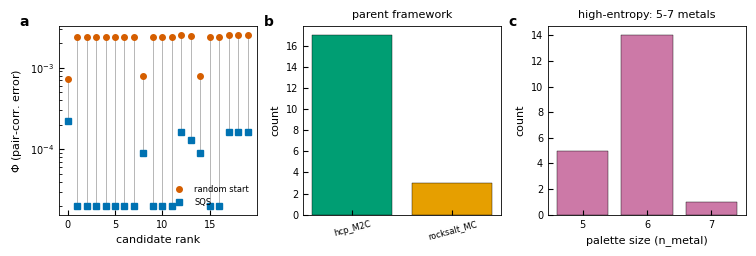

median Phi reduction: 159x


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(7.6, 2.6))
for a, ch in zip(ax, 'abc'):
    a.text(-0.20, 1.06, ch, transform=a.transAxes, fontsize=10, fontweight='bold', va='top')
# (a) Phi random vs SQS per candidate
x = np.arange(len(s))
ax[0].semilogy(x, s.phi_random, 'o', color=OI['vermil'], ms=4, label='random start')
ax[0].semilogy(x, s.phi_sqs.clip(lower=1e-6), 's', color=OI['blue'], ms=4, label='SQS')
for xi, (pr, ps) in enumerate(zip(s.phi_random, s.phi_sqs.clip(lower=1e-6))):
    ax[0].plot([xi, xi], [ps, pr], color='gray', lw=0.4, zorder=0)
ax[0].set_xlabel('candidate rank'); ax[0].set_ylabel(r'$\Phi$ (pair-corr. error)')
ax[0].legend(loc='lower right', fontsize=6)
# (b) framework distribution
fc = s.framework.value_counts()
ax[1].bar(range(len(fc)), fc.values, color=[OI['green'], OI['orange']][:len(fc)],
          edgecolor='black', linewidth=0.3)
ax[1].set_xticks(range(len(fc))); ax[1].set_xticklabels(fc.index, rotation=15, fontsize=6)
ax[1].set_ylabel('count'); ax[1].set_title('parent framework', fontsize=8)
# (c) palette size
pc = s.n_palette.value_counts().sort_index()
ax[2].bar(pc.index, pc.values, color=OI['purple'], edgecolor='black', linewidth=0.3)
ax[2].set_xlabel('palette size (n_metal)'); ax[2].set_ylabel('count')
ax[2].set_title('high-entropy: 5-7 metals', fontsize=8)
fig.tight_layout()
for ext in ('pdf','png'):
    fig.savefig(FIG / f'fig7_sqs_quality.{ext}'); print('saved', FIG / f'fig7_sqs_quality.{ext}')
plt.show()
print('median Phi reduction: %.0fx' % s.phi_reduction.replace(np.inf, np.nan).median())

## 2. Representative solid solution

Load one SQS supercell and confirm near-equimolar metal occupation on the fixed
framework — this is the actual high-entropy carbide handed to Stage B.

In [3]:
from pymatgen.core import Structure
from collections import Counter
row = s.iloc[0]
st = Structure.from_file(str(SQS / row['cif']))
el = Counter(site.species_string for site in st)
metals = {k: v for k, v in el.items() if k != 'C'}
print(f"rank {row['rank']}: {row['source_formula']}  ->  {row['sqs_formula']}")
print(f"framework={row['framework']}, {len(st)} atoms, {row['n_metal_sites']} metal sites")
print('metal occupation (near-equimolar):', dict(sorted(metals.items())))
print('carbon sites:', el.get('C', 0))
print(f"SQS Phi: {row['phi_random']:.4f} (random) -> {row['phi_sqs']:.4f} ({row['phi_reduction']:.0f}x lower)")

rank 1: SmGd3HoRe2GeMo3WC7  ->  Sm8Gd8Ho8Re8Ge8Mo7W7C27
framework=hcp_M2C, 81 atoms, 54 metal sites
metal occupation (near-equimolar): {'Gd': 8, 'Ge': 8, 'Ho': 8, 'Mo': 7, 'Re': 8, 'Sm': 8, 'W': 7}
carbon sites: 27
SQS Phi: 0.0007 (random) -> 0.0002 (3x lower)


/home/work/OxideMatterGen/.venv/lib/python3.10/site-packages/pymatgen/io/cif.py:1304: UserWarning: Issues encountered while parsing CIF: 36 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))


## 3. Stage B input shortlist

The solid solutions, ranked by entropy, that will go to fairchem surface
ΔG_H* screening. `best_site`/`frac_tn` are the Stage-A composition-proxy values
(to be replaced by real surface ΔG_H* in Stage B).

In [4]:
cols = ['rank','sqs_formula','framework','n_metal_sites','S_mix','best_site','frac_tn','w','phi_sqs']
shortlist = s[cols].sort_values('S_mix', ascending=False)
print(shortlist.to_string(index=False))
print(f'\n{len(s)} solid-solution supercells ready in outputs/sqs/ for Stage B.')

 rank              sqs_formula   framework  n_metal_sites  S_mix  best_site  frac_tn    w  phi_sqs
    1  Sm8Gd8Ho8Re8Ge8Mo7W7C27     hcp_M2C             54  1.820       0.00 1.000000 w2p5  0.00022
    2            TmReGeMoRuWC3     hcp_M2C             54  1.748       0.00 1.000000 w2p5  0.00002
    3           GdLuGeMoOsRuC3     hcp_M2C             54  1.735       0.00 1.000000 w2p5  0.00002
    4            HoGeMoOsRuWC3     hcp_M2C             54  1.721       0.00 1.000000 w2p5  0.00002
    5           TbDyGeIrOsRuC3     hcp_M2C             54  1.707      -0.05 1.000000 w2p5  0.00002
    6            SmReGeMoIrWC3     hcp_M2C             54  1.692       0.00 1.000000 w2p5  0.00002
    7            CeNdGdOsRuWC3     hcp_M2C             54  1.642      -0.05 1.000000 w2p5  0.00002
    8            PrDyTmGeOsWC3     hcp_M2C             54  1.635      -0.05 1.000000 w2p5  0.00002
    9           SmGdCrReMoRuC6 rocksalt_MC            108  1.633       0.00 1.000000 w2p5  0.00009
   10     